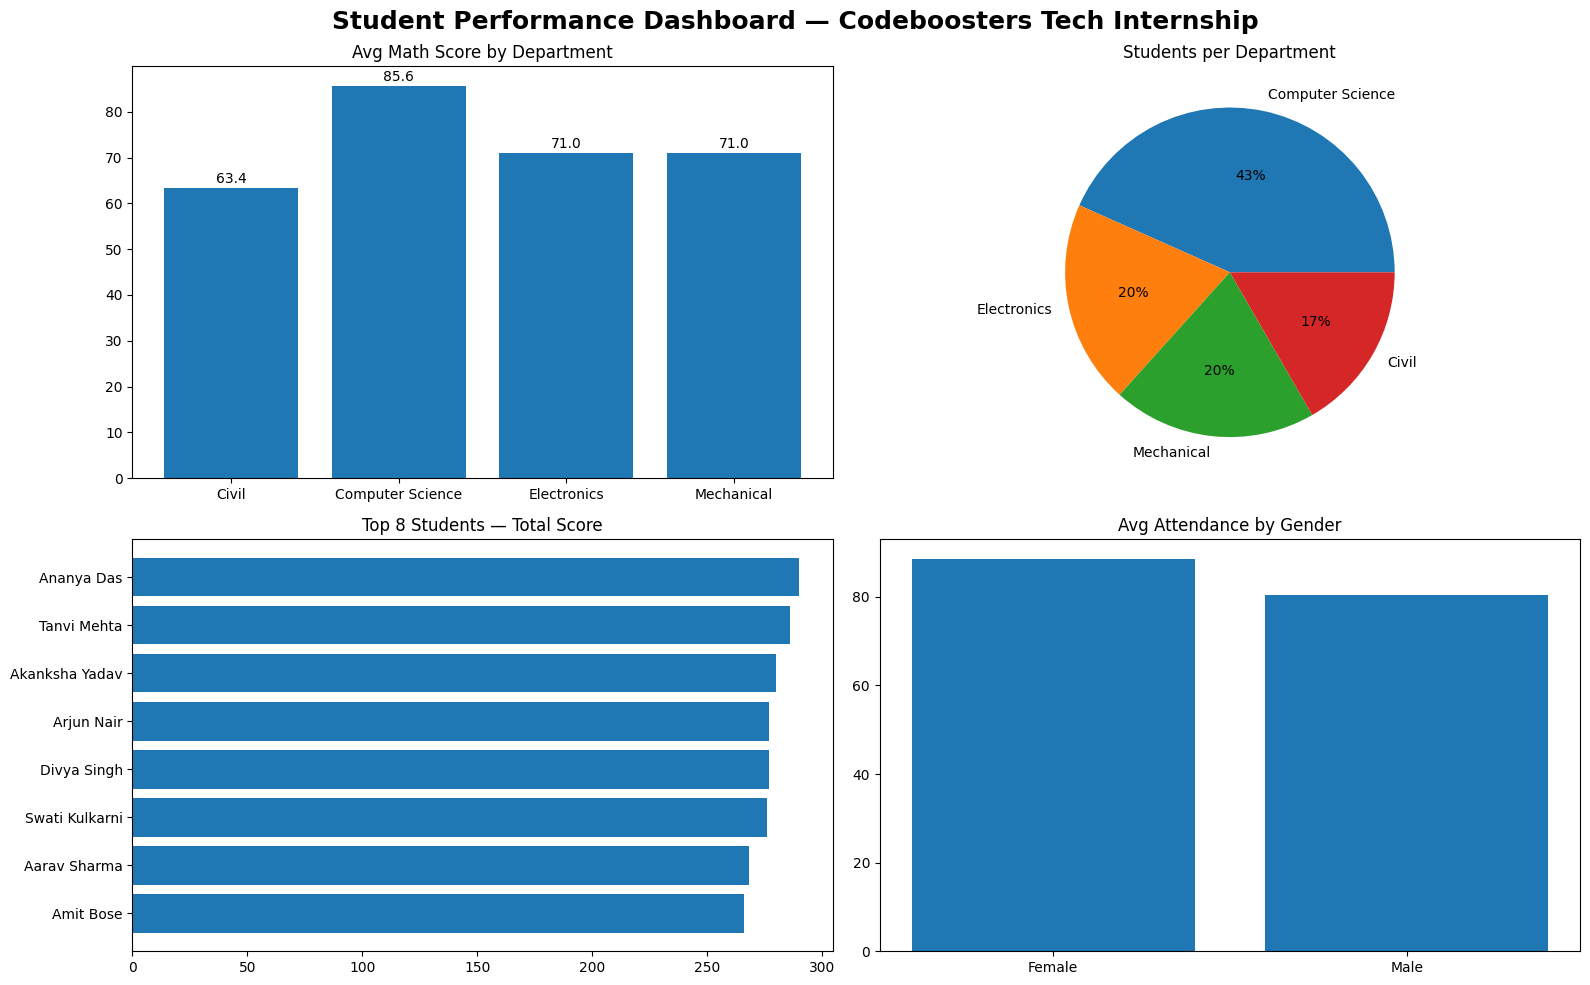

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("student_performance.csv")

df["total_score"] = (
    df["math_score"] +
    df["programming_score"] +
    df["attendance_percentage"]
)

avg_math = df.groupby("department")["math_score"].mean()

dept_count = df["department"].value_counts()

top_students = df.sort_values(
    by="total_score",
    ascending=False
).head(8)

gender_attendance = df.groupby("gender")[
    "attendance_percentage"
].mean()


fig, axes = plt.subplots(2, 2, figsize=(16,10))

axes[0,0].bar(
    avg_math.index,
    avg_math.values
)

axes[0,0].set_title("Avg Math Score by Department")

for i, value in enumerate(avg_math.values):
    axes[0,0].text(
        i,
        value + 1,
        f"{value:.1f}",
        ha='center'
    )

axes[0,1].pie(
    dept_count.values,
    labels=dept_count.index,
    autopct='%1.0f%%'
)

axes[0,1].set_title("Students per Department")

axes[1,0].barh(
    top_students["name"],
    top_students["total_score"]
)

axes[1,0].invert_yaxis()

axes[1,0].set_title("Top 8 Students — Total Score")

axes[1,1].bar(
    gender_attendance.index,
    gender_attendance.values
)

axes[1,1].set_title("Avg Attendance by Gender")

fig.suptitle(
    "Student Performance Dashboard — Codeboosters Tech Internship",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()